## **INDIAN TECH JOBS ANALYSIS**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data=pd.read_csv(r"D:\Analytics\All Projects\Indian Job Market Analysis\india_job_market_2024_2026.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Job_ID              5000 non-null   object 
 1   Job_Title           5000 non-null   object 
 2   Company             5000 non-null   object 
 3   Company_Type        5000 non-null   object 
 4   Industry            5000 non-null   object 
 5   City                5000 non-null   object 
 6   Location_Tier       5000 non-null   object 
 7   Experience_Level    5000 non-null   object 
 8   Job_Type            5000 non-null   object 
 9   Work_Mode           5000 non-null   object 
 10  Salary_LPA          5000 non-null   float64
 11  Skills_Required     5000 non-null   object 
 12  Education_Required  5000 non-null   object 
 13  Openings            5000 non-null   int64  
 14  Applicants          5000 non-null   int64  
 15  Company_Rating      5000 non-null   float64
 16  Date_P

In [5]:
data['Date_Posted']=pd.to_datetime(data['Date_Posted'])

In [16]:
data.head()

,Job_ID,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,Salary_LPA,Skills_Required,Education_Required,Openings,Applicants,Company_Rating,Date_Posted
0,IND2025000,Android Developer,Tech Mahindra,MNC,Information Technology,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,30.9,"Kotlin, Java, REST APIs",M.Tech/M.E.,3,276,4.0,2025-10-31
1,IND2025001,QA Engineer,Dream11,Indian Unicorn,Information Technology,Lucknow,Tier 2,Senior (6-10 yrs),Full-Time,Hybrid,58.6,"Selenium, Manual Testing, Postman, API Testing...",B.Tech/B.E.,3,325,4.0,2025-05-19
2,IND2025002,Business Analyst,HAL,PSU/Govt,EdTech,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,18.4,"JIRA, Excel, Power BI",MCA,5,559,3.6,2024-08-21
3,IND2025003,Cybersecurity Analyst,Groww,Startup,Information Technology,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,Hybrid,21.7,"Penetration Testing, Python, Ethical Hacking, ...",BCA,3,184,3.5,2026-03-18
4,IND2025004,Python Developer,Oracle,MNC,EdTech,Remote,Remote,Junior (1-3 yrs),Full-Time,Remote,8.0,"Docker, REST APIs, AWS, PostgreSQL",MCA,1,64,3.9,2024-10-25


**KPI**

1. Total Applicants

In [20]:
applicants=data['Applicants'].sum()
print(f'There are {applicants} no. of total applicants')

There are 1510360 no. of total applicants


2. Average Salary

In [23]:
avg_salary=data['Salary_LPA'].mean().round(2)
print(f'Overall Average Salary across all jobs is {avg_salary} LPA')

Overall Average Salary across all jobs is 19.83 LPA


3. Total Openings

In [24]:
openings=data['Openings'].sum()
print(f'Total Openings: {openings}')

Total Openings: 18213


4. Applicant to Opening Ratio

In [26]:
ratio=(applicants/openings).round(2)
print(f'Applicant to Opening Ratio: {ratio}')

Applicant to Opening Ratio: 82.93


**THE HIGH RATIO SHOWS HIGH COMPETITIVE JOB MARKET**

5. Remote Job Precentage

In [27]:
pct=((data['Work_Mode']=='Remote').mean())*100
print(f'Remote Job Percentage: {pct}')

Remote Job Percentage: 25.34


6. Average Salary by Experience Level

In [41]:
res=data.groupby('Experience_Level')['Salary_LPA'].mean().round(2).sort_values().reset_index(name='Average_Salary_LPA')
res

,Experience_Level,Average_Salary_LPA
0,Fresher (0-1 yr),5.50
1,Junior (1-3 yrs),9.92
2,Mid (3-6 yrs),18.50
3,Senior (6-10 yrs),34.19
4,Lead (10+ yrs),52.95


**1.MOST IN DEMAND ROLES**

In [32]:
top_roles=data['Job_Title'].value_counts().sort_values(ascending=False).reset_index()
top_roles.head()

,Job_Title,count
0,Software Engineer,336
1,Backend Developer,278
2,Full Stack Developer,260
3,Data Analyst,254
4,Java Developer,249


**INSIGHT:- Software Engineer, Backend Developer, Full Stack Developer and Data Analyst roles dominate the Indian tech hiring market, indicating sustained demand for technical and analytical talent.**

*Which Roles has high applicants*

In [37]:
res=data.groupby('Job_Title').agg({
    'Applicants': 'sum',
    'Openings': 'sum'
}).sort_values(by=['Applicants'],ascending=False).reset_index()
res.head()

,Job_Title,Applicants,Openings
0,Software Engineer,102742,1253
1,Backend Developer,86713,1041
2,Full Stack Developer,81809,975
3,Data Analyst,75411,931
4,Java Developer,72678,911


**2. SALARY INTELLIGENCE**

*Highest Paying Roles*

In [39]:
res=data.groupby('Job_Title')['Salary_LPA'].mean().round(2).sort_values(ascending=False).reset_index(name='Avg_Salary_LPA')
res.head()

,Job_Title,Avg_Salary_LPA
0,Research Scientist,26.04
1,AI Engineer,24.86
2,Data Scientist,24.26
3,Computer Vision Engineer,23.26
4,NLP Engineer,22.42


*Salary by Company Type*

In [10]:
res=data.groupby('Company_Type')['Salary_LPA'].mean().sort_values().round(2).reset_index(name='Avg_Salary')
res

,Company_Type,Avg_Salary
0,PSU/Govt,10.75
1,MNC,18.45
2,Startup,21.52
3,Indian Unicorn,24.62


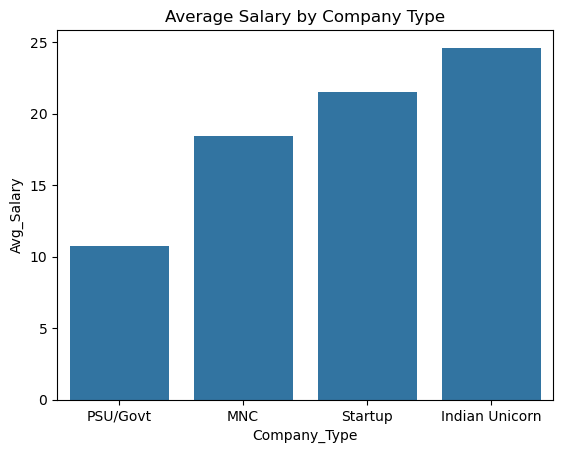

In [12]:
sns.barplot(res,x='Company_Type',y='Avg_Salary')
plt.title('Average Salary by Company Type')
plt.show()

**INDIAN UNICORN GIVES HIGH AVERAGE SALARY AS COMPARED TO OTHERS. WHILE GOVT/PSU HAS THE LOWEST(JUST LIKE REAL LIFE)**

In [14]:
res=data.groupby('Company_Type')['Openings'].sum().sort_values().reset_index(name='Total_Openings')
res

,Company_Type,Total_Openings
0,PSU/Govt,2383
1,Indian Unicorn,4352
2,Startup,5147
3,MNC,6331


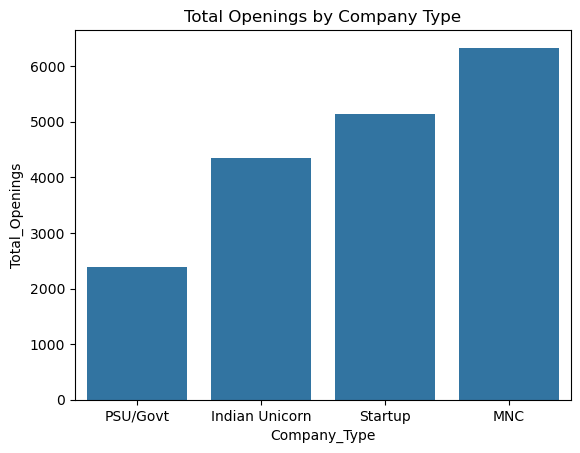

In [15]:
sns.barplot(res,x='Company_Type',y='Total_Openings')
plt.title('Total Openings by Company Type')
plt.show()

**MNC create large number of openings**

**2. CITY WISE HIRING TREND(TIER WISE)**

In [18]:
res=data.groupby('Location_Tier')['Salary_LPA'].mean().round(2).reset_index(name='Avg_Salary_LPA')
res

,Location_Tier,Avg_Salary_LPA
0,Remote,19.86
1,Tier 1,19.96
2,Tier 2,19.46


*WHICH CITIES HIRES THE MOST*

In [49]:
res=data.groupby('City')['Openings'].sum().reset_index()
res.sort_values(by='Openings',ascending=False,inplace=True)
total=res['Openings'].sum()
res['Open_%']=(res['Openings']/total)*100
res.head()

,City,Openings,Open_%
16,Remote,7009,38.483501
15,Pune,1490,8.180970
13,Mumbai,1366,7.500137
7,Hyderabad,1322,7.258552
6,Delhi,1222,6.709493


**Remote hiring has 38% of market hiring share**

*Which City Pays the highest*

In [53]:
res=data.groupby('City')['Salary_LPA'].mean().round(2).reset_index()
res.sort_values(by='Salary_LPA',ascending=False,inplace=True)
res.head()

,City,Salary_LPA
11,Kolkata,23.78
2,Bhubaneswar,22.26
9,Jaipur,21.09
15,Pune,20.89
8,Indore,20.79


*Applicants count by work mode*

In [55]:
res=data.groupby('Work_Mode')['Applicants'].sum().sort_values(ascending=False).reset_index()
res

,Work_Mode,Applicants
0,On-Site,608255
1,Hybrid,538809
2,Remote,363296


**On-site jobs attracts more applicants than remote jobs,indicating strong preference for on-site work**

**SKILLS DEMAND ANALYSIS**

In [59]:
skills=data['Skills_Required'].str.split(',')
skills_exploded=skills.explode()

*MOST DEMANDED SKILL*

In [61]:
demand=(skills_exploded.str.split().value_counts().reset_index())
demand.head(10)

,Skills_Required,count
0,[Python],1579
1,"[REST, APIs]",998
2,[AWS],867
3,[SQL],847
4,[Docker],836
5,[Java],636
6,[PostgreSQL],455
7,[React],454
8,[TypeScript],440
9,[Agile],429


*HIGHEST PAYING SKILL*

In [63]:
skill_data = skill_salary.groupby('Skills_Required').agg({
    'Salary_LPA':'mean',
    'Job_ID':'count'
}).reset_index()

skill_data.columns = [
    'Skill',
    'Average_Salary_LPA',
    'Demand_Count'
]

skill_data = skill_data[
    skill_data['Demand_Count'] >= 10
]

skill_data = skill_data.sort_values(
    by='Average_Salary_LPA',
    ascending=False
)

skill_data.head(10)

,Skill,Average_Salary_LPA,Demand_Count
103,Vector DBs,26.612245,98
50,Machine Learning,26.577083,96
71,Publications,25.676596,47
20,Deep Learning,25.609500,200
75,RAG,25.582927,82
46,LangChain,25.566250,80
61,OpenCV,25.090385,52
55,NLP,25.068511,235
60,OpenAI API,24.606452,93
84,Scikit-learn,23.815183,191


**Time Trend Analysis**

In [75]:
#---monthly hiring trend---
data['Month'] = data['Date_Posted'].dt.month_name()
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]
res = (
    data['Month']
    .value_counts()
    .reindex(month_order)
    .reset_index()
)
res.columns=['Month','Total_Hiring']
res

,Month,Total_Hiring
0,January,421
1,February,399
2,March,456
3,April,437
4,May,213
5,June,434
6,July,433
7,August,433
8,September,458
9,October,472


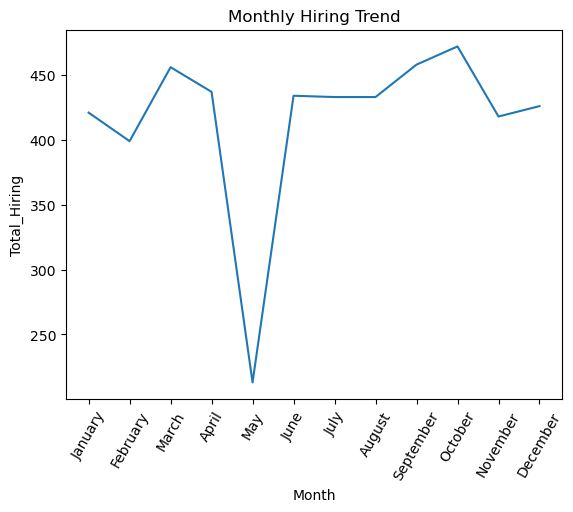

In [78]:
sns.lineplot(res,x='Month',y='Total_Hiring')
plt.title('Monthly Hiring Trend')
plt.xticks(rotation=60)
plt.show()